# Simulate template stimulus responses

Loads a template waveform from `data/template_waveforms.pkl` (generated by `26_05_26_generate_template_waveforms.ipynb`) and runs multi-trial simulations.

**Run the generate notebook first** if `data/template_waveforms.pkl` does not exist.

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
from pathlib import Path

plt.style.use(Path('..') / 'configs' / 'mpl.mplstyle')

from designer_waveform.models import RandomEINetwork, load_config
from designer_waveform.optics import OpticsConfig, SigmoidPowerCurve
from designer_waveform.waveforms import RectangularPulseWaveform, PulseTrainWaveform

In [9]:
# ── Waveform source ───────────────────────────────────────────────────────
# 'template'   : load from data/template_waveforms.pkl
#                Set TEMPLATE_NAME to one of: 'pulse_25ms', 'pulse_135ms', 'train_25hz_1s'
# 'optimised'  : load opt_waveform from an optimisation result pkl
#                Set OPT_RESULT_PATH to the relevant file
# 'pulse_train': build a PulseTrainWaveform directly from parameters below
WAVEFORM_SOURCE = 'optimised'
TEMPLATE_NAME   = 'pulse_25ms'
OPT_RESULT_PATH = Path('../results/optimised_waveforms/increasing_l23/l23_chrmine/increasing_l23_l23_optimisation_result.pkl')

# ── Pulse train parameters (used only when WAVEFORM_SOURCE = 'pulse_train') ──
PT_FREQ_HZ       = 25.0    # pulse repetition frequency (Hz)
PT_PULSE_DUR_MS  = 25.0    # width of each individual pulse (ms)
PT_TRAIN_DUR_MS  = 250.0   # total duration of the train (ms)
PT_AMPLITUDE_MW  = 4.55    # peak source power per pulse (mW)

# ── Silence padding ───────────────────────────────────────────────────────
PRE_SILENCE_MS  = 20.0
POST_SILENCE_MS = 100.0

# ── PSTH bin size ────────────────────────────────────────────────────────
BIN_SIZE_MS = 10.0

# ── Multi-run settings ───────────────────────────────────────────────────
N_RUNS    = 20
SEED_BASE = 1000

VARY_INIT_V       = True
VARY_CONNECTIVITY = True
VARY_WEIGHTS      = True

# ── Power mode ────────────────────────────────────────────────────────────
USE_POWER_MODE    = True
RESCALE_AMPLITUDE = False
AMPLITUDE_MW      = 4.55

# ── Opsin ─────────────────────────────────────────────────────────────────
# 'c1v1'    : C1V1-A  (i_max ≈ 1175 pA, K½ ≈ 0.0015 mW/mm²,  sat ~0.1 mW/mm²)
# 'chrmine' : ChRmine (i_max ≈ 4600 pA, K½ ≈ 0.037  mW/mm²,  sat ~0.7 mW/mm²)
OPSIN = 'chrmine'

# ── Square-pulse comparison (cell below) ──────────────────────────────────
INCLUDE_PEAK_MATCHED = False

In [10]:
if WAVEFORM_SOURCE == 'template':
    TEMPLATES_PATH = Path('../data/template_waveforms.pkl')
    with open(TEMPLATES_PATH, 'rb') as f:
        templates = pickle.load(f)
    if TEMPLATE_NAME not in templates:
        raise KeyError(f'TEMPLATE_NAME={TEMPLATE_NAME!r} not found. Available: {list(templates)}')
    _entry         = templates[TEMPLATE_NAME]
    _inner_wf      = _entry['waveform']
    _orig_stim_dur = float(_entry['stim_dur_ms'])
    description    = _entry['description']
    _label         = TEMPLATE_NAME

elif WAVEFORM_SOURCE == 'optimised':
    with open(OPT_RESULT_PATH, 'rb') as f:
        _opt = pickle.load(f)
    _inner_wf      = _opt['opt_waveform']
    _orig_stim_dur = float(_opt['stim_dur_ms'])
    description    = f"Optimised waveform ({_opt['source']} / {_opt['target_layer']})"
    _label         = f"optimised_{_opt['source']}_{_opt['target_layer']}"

elif WAVEFORM_SOURCE == 'pulse_train':
    _inner_wf = PulseTrainWaveform(
        onset_ms          = 0.0,
        pulse_duration_ms = PT_PULSE_DUR_MS,
        frequency_hz      = PT_FREQ_HZ,
        train_duration_ms = PT_TRAIN_DUR_MS,
        amplitude         = PT_AMPLITUDE_MW,
    )
    _orig_stim_dur = PT_TRAIN_DUR_MS
    description    = (f'Pulse train: {PT_FREQ_HZ:.0f} Hz, '
                      f'{PT_PULSE_DUR_MS:.0f} ms pulses, '
                      f'{PT_TRAIN_DUR_MS:.0f} ms duration, '
                      f'{PT_AMPLITUDE_MW:.2f} mW')
    _label         = f'train_{PT_FREQ_HZ:.0f}hz_{PT_PULSE_DUR_MS:.0f}ms_{PT_AMPLITUDE_MW:.2f}mw'

else:
    raise ValueError(f"WAVEFORM_SOURCE={WAVEFORM_SOURCE!r} must be 'template', 'optimised', or 'pulse_train'")

print(f'Source         : {WAVEFORM_SOURCE}')
print(f'Description    : {description}')
print(f'Waveform       : {_inner_wf}')
print(f'Inner duration : {_orig_stim_dur:.0f} ms')
print(f'With padding   : {PRE_SILENCE_MS:.0f} + {_orig_stim_dur:.0f} + {POST_SILENCE_MS:.0f} = '
      f'{PRE_SILENCE_MS + _orig_stim_dur + POST_SILENCE_MS:.0f} ms total')

Source         : optimised
Description    : Optimised waveform (increasing_l23 / all)
Waveform       : AsymBaselineSplitGaussianWaveform(amplitude=0.188, mu=61.3, sigma_rise=11.7, sigma_fall=45.2, baseline_rise=7.4e-06, baseline_fall=1.02e-05)
Inner duration : 250 ms
With padding   : 20 + 250 + 100 = 370 ms total


In [11]:
# ── Extend stim window with silence buffers ───────────────────────────────
STIM_DUR_MS = PRE_SILENCE_MS + _orig_stim_dur + POST_SILENCE_MS

CONFIG_PATH = Path('..') / 'configs' / 'random_ei.json'
cfg = load_config(CONFIG_PATH)
# All network parameters (N_exc, N_inh, t_pre_ms, t_post_ms, I_bg_exc_pA, ...)
# are read directly from the config — no overrides here.
cfg.t_stim_ms   = STIM_DUR_MS
cfg.psth_bin_ms = BIN_SIZE_MS

if USE_POWER_MODE:
    _optics         = OpticsConfig.from_file(Path('..') / 'data' / 'optics_params.json')
    _curve          = {'c1v1': SigmoidPowerCurve.c1v1, 'chrmine': SigmoidPowerCurve.chrmine}[OPSIN]()
    model           = RandomEINetwork(cfg, optics=_optics, power_curve=_curve,
                                      normalization='max_expression')
    _max_irr_mw_mm2 = {'c1v1': 0.1, 'chrmine': 0.7}[OPSIN]
    MAX_POWER_MW    = _optics.area_mm2 * _max_irr_mw_mm2 / _optics.total_transmission
    _amp_label = 'mW'
    if RESCALE_AMPLITUDE:
        _peak  = max(_inner_wf(np.linspace(0, _orig_stim_dur, 1000)).max(), 1e-9)
        _scale = AMPLITUDE_MW / _peak
        _amp_tag = f'{AMPLITUDE_MW:.2f}mw'
        print(f'Power mode ON  — rescaled to {AMPLITUDE_MW:.2f} mW peak')
    else:
        _scale   = 1.0
        _amp_tag = 'native_mw'
        print(f'Power mode ON  — native amplitude (no rescaling)')
    print(f'               opsin: {OPSIN}  i_max={_curve.i_max_pA:.0f} pA  '
          f'K½={_curve.half_sat_mW_mm2} mW/mm²')
    print(f'               max deliverable: {MAX_POWER_MW:.2f} mW')
else:
    model        = RandomEINetwork(cfg)
    MAX_POWER_MW = None
    _scale       = 1.0
    _amp_label   = 'AU'
    _amp_tag     = 'au'
    print('Power mode OFF — amplitude in AU [0, 1]')

# ── Build padded waveform: silence → scaled stimulus → silence ────────────
_base_wf = _inner_wf
_pre_s, _dur_s, _sc = PRE_SILENCE_MS, _orig_stim_dur, _scale

def waveform(t, _w=_base_wf, _pre=_pre_s, _dur=_dur_s, _s=_sc):
    t    = np.asarray(t, dtype=float)
    mask = (t >= _pre) & (t < _pre + _dur)
    out  = np.zeros_like(t)
    if mask.any():
        out[mask] = _w(t[mask] - _pre) * _s
    return out

_run_tag   = f'{_label}_{OPSIN}_{_amp_tag}'
OUTPUT_DIR = Path('../results') / 'template_responses' / _run_tag
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f'Config: N_exc={cfg.N_exc}, N_inh={cfg.N_inh}, '
      f't_pre={cfg.t_pre_ms:.0f} ms, I_bg={cfg.I_bg_exc_pA:.0f} pA')
print(f'Stim window: {_orig_stim_dur:.0f} ms + {PRE_SILENCE_MS:.0f} ms pre '
      f'+ {POST_SILENCE_MS:.0f} ms post = {STIM_DUR_MS:.0f} ms total')
print(f'Opsin mean: {model._stim_dist_pA.mean():.1f} pA, '
      f'frac zero: {(model._stim_dist_pA == 0).mean():.3f}')
print(f'Output dir : {OUTPUT_DIR}')

Power mode ON  — native amplitude (no rescaling)
               opsin: chrmine  i_max=4600 pA  K½=0.037 mW/mm²
               max deliverable: 31.86 mW
Config: N_exc=8000, N_inh=2000, t_pre=500 ms, I_bg=260 pA
Stim window: 250 ms + 20 ms pre + 100 ms post = 370 ms total
Opsin mean: 420.5 pA, frac zero: 0.168
Output dir : ../results/template_responses/optimised_increasing_l23_all_chrmine_native_mw


  I_bg_exc =   50.0 pA  →  0.00 Hz  (12.9 s)
  I_bg_exc =  100.0 pA  →  0.00 Hz  (11.5 s)
  I_bg_exc =  150.0 pA  →  1.74 Hz  (9.9 s)
  I_bg_exc =  200.0 pA  →  3.55 Hz  (9.9 s)
  I_bg_exc =  250.0 pA  →  5.45 Hz  (10.1 s)
  I_bg_exc =  300.0 pA  →  7.26 Hz  (10.7 s)


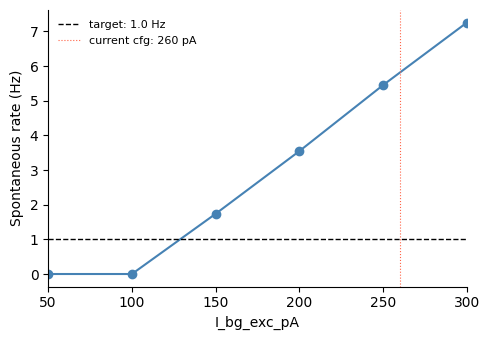


→ Suggested I_bg_exc_pA: 128.8 pA
  Apply by setting cfg.I_bg_exc_pA below and re-running this cell:
  cfg.I_bg_exc_pA = 128.8
  Applied. Model rebuilt.


In [12]:
# ── Background drive sweep ────────────────────────────────────────────────
# Runs the model with a zero-amplitude waveform at several I_bg_exc_pA
# values to find the setting that gives the target spontaneous firing rate.
# Adjust BG_VALUES_pA and TARGET_BASELINE_HZ, then re-run.
# Apply the suggested value by setting cfg.I_bg_exc_pA below and
# re-running this cell.
import time as _time

TARGET_BASELINE_HZ = 1.0
BG_VALUES_pA       = [50.0, 100.0, 150.0, 200.0, 250.0, 300.0]

_zero_wf    = lambda t: np.zeros_like(np.asarray(t, dtype=float))
_orig_bg    = float(cfg.I_bg_exc_pA)
_bg_results = []   # (bg_pA, mean_hz)

for _bg in BG_VALUES_pA:
    cfg.I_bg_exc_pA = float(_bg)
    _m_tmp = RandomEINetwork(cfg, **({
        'optics': _optics, 'power_curve': _curve, 'normalization': 'max_expression'
    } if USE_POWER_MODE else {}))
    _t0  = _time.time()
    _out = _m_tmp.run(_zero_wf)
    _hz  = float(_out['psth_exc'].mean() / (BIN_SIZE_MS / 1000.0))
    _bg_results.append((_bg, _hz))
    print(f'  I_bg_exc = {_bg:>6.1f} pA  →  {_hz:.2f} Hz  ({_time.time()-_t0:.1f} s)')

cfg.I_bg_exc_pA = _orig_bg   # restore until user applies

_bgs  = np.array([r[0] for r in _bg_results])
_rates = np.array([r[1] for r in _bg_results])

fig, ax = plt.subplots(figsize=(5, 3.5))
ax.plot(_bgs, _rates, 'o-', color='steelblue', lw=1.5)
ax.axhline(TARGET_BASELINE_HZ, color='k', lw=1, ls='--',
           label=f'target: {TARGET_BASELINE_HZ:.1f} Hz')
ax.axvline(_orig_bg, color='tomato', lw=0.8, ls=':',
           label=f'current cfg: {_orig_bg:.0f} pA')
ax.set_xlabel('I_bg_exc_pA')
ax.set_ylabel('Spontaneous rate (Hz)')
ax.legend(frameon=False, fontsize=8)
ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout()
plt.show()

if _rates.min() <= TARGET_BASELINE_HZ <= _rates.max():
    _order     = np.argsort(_rates)
    _suggested = float(np.interp(TARGET_BASELINE_HZ, _rates[_order], _bgs[_order]))
    print(f'\n→ Suggested I_bg_exc_pA: {_suggested:.1f} pA')
    print('  Apply by setting cfg.I_bg_exc_pA below and re-running this cell:')
    print(f'  cfg.I_bg_exc_pA = {_suggested:.1f}')
    # ── Apply ──────────────────────────────────────────────────────────
    cfg.I_bg_exc_pA = _suggested
    model = RandomEINetwork(cfg, **({
        'optics': _optics, 'power_curve': _curve, 'normalization': 'max_expression'
    } if USE_POWER_MODE else {}))
    print(f'  Applied. Model rebuilt.')
elif _rates.max() < TARGET_BASELINE_HZ:
    print(f'\n→ All values below target. Extend BG_VALUES_pA above {BG_VALUES_pA[-1]:.0f} pA.')
else:
    print(f'\n→ All values above target. Extend BG_VALUES_pA below {BG_VALUES_pA[0]:.0f} pA.')

## Waveform preview

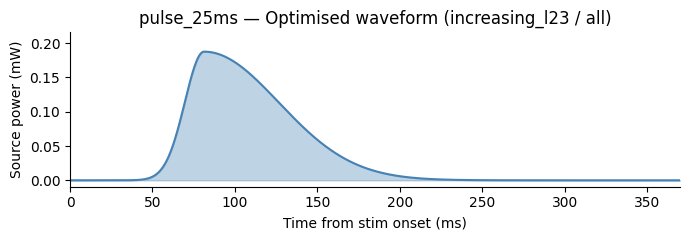

In [13]:
_t_plot  = np.linspace(0, STIM_DUR_MS, int(STIM_DUR_MS / 0.1))
_wf_vals = waveform(_t_plot)
_ylim    = (-0.05 * _wf_vals.max(), _wf_vals.max() * 1.15)

fig, ax = plt.subplots(figsize=(max(7, STIM_DUR_MS / 80), 2.5))
ax.fill_between(_t_plot, 0, _wf_vals, alpha=0.35, color='steelblue')
ax.plot(_t_plot, _wf_vals, color='steelblue', lw=1.5)
ax.set_xlim(0, STIM_DUR_MS)
ax.set_ylim(*_ylim)
ax.set_xlabel('Time from stim onset (ms)')
ax.set_ylabel(f'Source power ({_amp_label})' if USE_POWER_MODE else 'Envelope amplitude (AU)')
ax.set_title(f'{TEMPLATE_NAME} — {description}')
ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'waveform.png', dpi=150)
plt.show()

## Multi-run simulation

In [14]:
_vary_str = ', '.join(
    s for s, v in [('init_v', VARY_INIT_V), ('connectivity', VARY_CONNECTIVITY),
                   ('weights', VARY_WEIGHTS)] if v
) or 'none'
print(f'Running {N_RUNS} simulations (varying: {_vary_str})...')

_all_psth  = []
_all_fine  = []
_spike_data_one = None   # store one run for raster

_fine_bin_ms   = max(1.0, BIN_SIZE_MS / 2.0)   # finer bin for display
_fine_edges    = np.arange(0, STIM_DUR_MS + _fine_bin_ms, _fine_bin_ms)
_fine_t        = 0.5 * (_fine_edges[:-1] + _fine_edges[1:])

for _i in range(N_RUNS):
    _r = model.run(waveform, seed=SEED_BASE + _i,
                   vary_init_v=VARY_INIT_V,
                   vary_connectivity=VARY_CONNECTIVITY,
                   vary_weights=VARY_WEIGHTS)
    _all_psth.append(_r['psth_exc'] / (BIN_SIZE_MS / 1000.0))

    _exc_m  = _r['spike_indices'] < cfg.N_exc
    _et     = _r['spike_times_ms'][_exc_m] - cfg.t_pre_ms
    _win    = (_et >= 0) & (_et <= STIM_DUR_MS)
    _cnt, _ = np.histogram(_et[_win], bins=_fine_edges)
    _all_fine.append(_cnt / cfg.N_exc / (_fine_bin_ms / 1000.0))

    if _i == 0:
        _spike_data_one = {
            'times':   _r['spike_times_ms'][_exc_m][_win] - 0,
            'indices': _r['spike_indices'][_exc_m][_win],
            'offset':  cfg.t_pre_ms,
        }
    if (_i + 1) % 5 == 0:
        print(f'  {_i + 1}/{N_RUNS}')

_psth_arr  = np.stack(_all_psth)
_fine_arr  = np.stack(_all_fine)
t_psth_ms  = model.run(waveform)['t_psth_ms']

mean_hz    = _psth_arr.mean(0)
sem_hz     = _psth_arr.std(0) / np.sqrt(N_RUNS)
mean_fine  = _fine_arr.mean(0)
sem_fine   = _fine_arr.std(0) / np.sqrt(N_RUNS)

print('Done.')

Running 20 simulations (varying: init_v, connectivity, weights)...
  5/20
  10/20
  15/20
  20/20
Done.


## Results

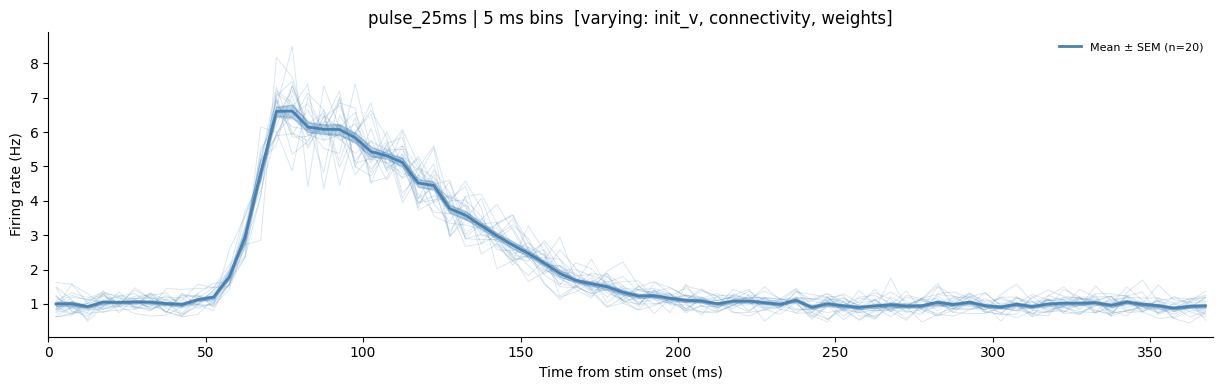

In [15]:
fig, ax = plt.subplots(figsize=(max(8, STIM_DUR_MS / 30), 4))

for _run_hz in _fine_arr:
    ax.plot(_fine_t, _run_hz, color='steelblue', lw=0.7, alpha=0.2)
ax.fill_between(_fine_t, mean_fine - sem_fine, mean_fine + sem_fine,
                color='steelblue', alpha=0.35)
ax.plot(_fine_t, mean_fine, color='steelblue', lw=2,
        label=f'Mean ± SEM (n={N_RUNS})')
ax.set_xlim(0, STIM_DUR_MS)
ax.set_xlabel('Time from stim onset (ms)')
ax.set_ylabel('Firing rate (Hz)')
ax.set_title(f'{TEMPLATE_NAME} | {_fine_bin_ms:.0f} ms bins  [varying: {_vary_str}]')
ax.legend(frameon=False, fontsize=8)
ax.spines[['top', 'right']].set_visible(False)

fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'psth.png', dpi=150)
plt.show()

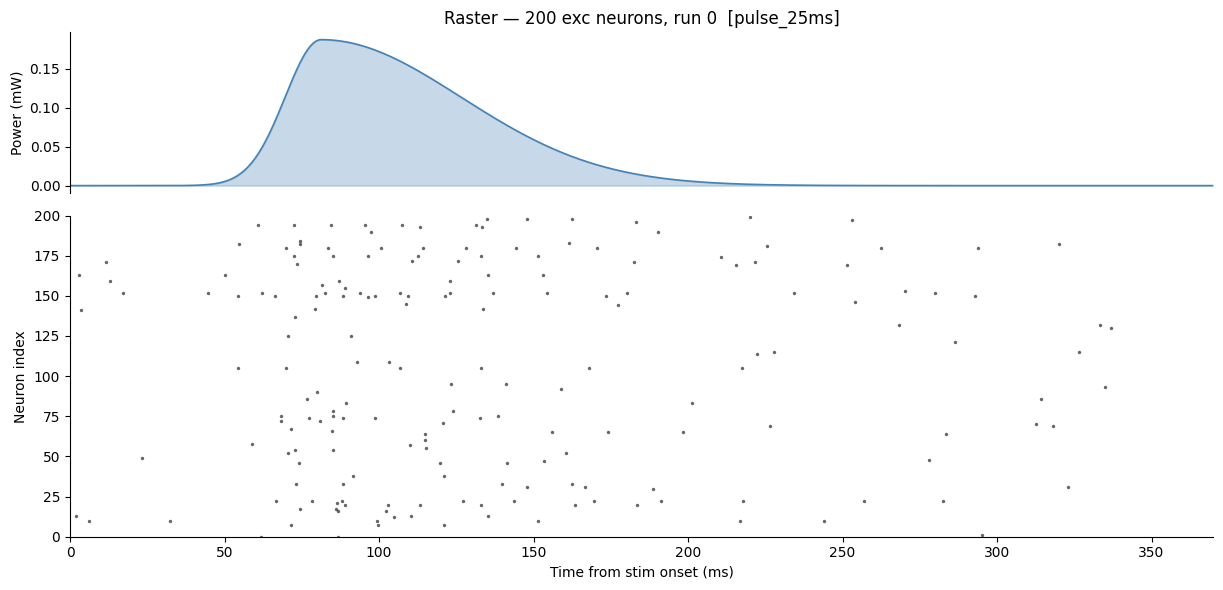

In [16]:
N_RASTER = 200   # neurons to show

_sd  = _spike_data_one
_st  = _sd['times'] - _sd['offset']
_si  = _sd['indices']
_win = (_st >= 0) & (_st <= STIM_DUR_MS)
_rm  = (_si < N_RASTER) & _win

fig, axes = plt.subplots(2, 1, figsize=(max(9, STIM_DUR_MS / 30), 6),
                          gridspec_kw={'height_ratios': [1, 2]})

ax = axes[0]
ax.fill_between(_t_plot, 0, _wf_vals, alpha=0.3, color='steelblue')
ax.plot(_t_plot, _wf_vals, color='steelblue', lw=1.2)
ax.set_xlim(0, STIM_DUR_MS)
ax.set_ylabel(f'Power ({_amp_label})' if USE_POWER_MODE else 'Envelope (AU)')
ax.set_title(f'Raster — {N_RASTER} exc neurons, run 0  [{TEMPLATE_NAME}]')
ax.tick_params(bottom=False, labelbottom=False)
ax.spines[['top', 'right', 'bottom']].set_visible(False)

ax = axes[1]
ax.scatter(_st[_rm], _si[_rm], s=6, color='k', alpha=0.6, linewidths=0)
ax.set_xlim(0, STIM_DUR_MS)
ax.set_ylim(0, N_RASTER)
ax.set_xlabel('Time from stim onset (ms)')
ax.set_ylabel('Neuron index')
ax.spines[['top', 'right']].set_visible(False)

fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'raster.png', dpi=150)
plt.show()

In [17]:
_save = {
    'template_name':    TEMPLATE_NAME if WAVEFORM_SOURCE == 'template' else None,
    'waveform_source':  WAVEFORM_SOURCE,
    'description':      description,
    'orig_stim_dur_ms': _orig_stim_dur,
    'pre_silence_ms':   PRE_SILENCE_MS,
    'post_silence_ms':  POST_SILENCE_MS,
    'stim_dur_ms':      STIM_DUR_MS,
    'bin_size_ms':      BIN_SIZE_MS,
    'fine_bin_ms':      _fine_bin_ms,
    'n_runs':           N_RUNS,
    'seed_base':        SEED_BASE,
    'use_power_mode':   USE_POWER_MODE,
    'rescale_amplitude': RESCALE_AMPLITUDE,
    'amplitude_mw':     AMPLITUDE_MW if (USE_POWER_MODE and RESCALE_AMPLITUDE) else None,
    'waveform_scale':   _scale,
    # original (un-padded, un-scaled) waveform — picklable
    # reconstruct full waveform with:
    #   out[t >= pre & t < pre+dur] = waveform(t[...] - pre) * waveform_scale
    'waveform':         _base_wf,
    't_psth_ms':        t_psth_ms,
    'runs_hz':          _psth_arr,
    'mean_hz':          mean_hz,
    'sem_hz':           sem_hz,
    'fine_t_ms':        _fine_t,
    'fine_mean_hz':     mean_fine,
    'fine_sem_hz':      sem_fine,
}
_save_path = OUTPUT_DIR / 'results.pkl'
with open(_save_path, 'wb') as f:
    pickle.dump(_save, f)
print(f'Saved to {_save_path}')

Saved to ../results/template_responses/optimised_increasing_l23_all_chrmine_native_mw/results.pkl


WARNING    /var/folders/8s/q649n2z56_1045fkqy4dygm00000gr/T/ipykernel_62183/1235205874.py:11: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  energy     = float(np.trapz(_w_eval, _t_eval))   # mW·ms
 [py.warnings]
WARNING    /var/folders/8s/q649n2z56_1045fkqy4dygm00000gr/T/ipykernel_62183/1235205874.py:31: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  _pt_unit_energy = float(np.trapz(np.clip(_pt_unit(_t_eval), 0, None), _t_eval))
 [py.warnings]


Waveform metrics (active window only):
  active duration : 250.0 ms
  peak power      : 0.1877 mW
  average power   : 0.0535 mW
  energy          : 13.384 mW·ms  =  0.01338 μJ

Energy-matched square pulse : 0.0535 mW × 250.0 ms
Energy-matched pulse train  : 0.0837 mW/pulse  (25 Hz, 25 ms pulses, 250 ms total)

Running 20 sims — Optimised ...
  5/20
  10/20
  15/20
  20/20

Running 20 sims — Energy-matched square pulse ...
  5/20
  10/20
  15/20
  20/20

Running 20 sims — Energy-matched pulse train ...
  5/20
  10/20
  15/20
  20/20


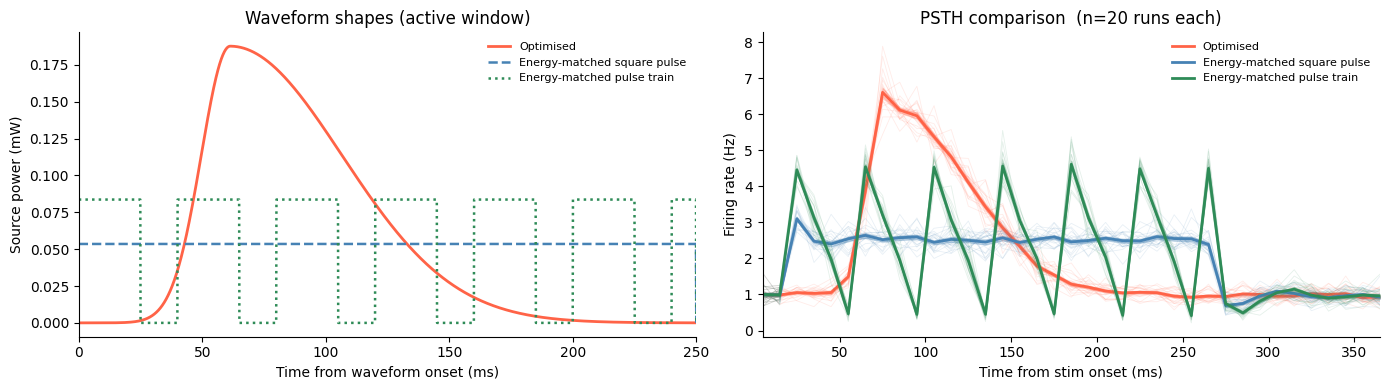

In [18]:
# ── Square-pulse comparison ───────────────────────────────────────────────
# All comparison waveforms are duration- and energy-matched to the loaded waveform:
#   Energy-matched square pulse : rect pulse, same active duration, amp = avg power
#   Energy-matched pulse train  : same freq/pulse-width as PT config, amp scaled
#                                 so total energy matches loaded waveform
# INCLUDE_PEAK_MATCHED (config cell) optionally adds a peak-power-matched rect.

# ── 1. Characterise the loaded waveform ──────────────────────────────────
_t_eval    = np.linspace(0, _orig_stim_dur, 20_000)
_w_eval    = np.clip(_inner_wf(_t_eval), 0, None)
energy     = float(np.trapz(_w_eval, _t_eval))   # mW·ms
avg_power  = energy / _orig_stim_dur              # mW
peak_power = float(_w_eval.max())                 # mW
dur_B      = energy / peak_power                  # ms (peak-matched pulse)

print('Waveform metrics (active window only):')
print(f'  active duration : {_orig_stim_dur:.1f} ms')
print(f'  peak power      : {peak_power:.4f} mW')
print(f'  average power   : {avg_power:.4f} mW')
print(f'  energy          : {energy:.3f} mW·ms  =  {energy * 1e-3:.5f} μJ')

# ── 2. Build comparison waveforms ─────────────────────────────────────────
# Energy-matched rectangle
pulse_rect = RectangularPulseWaveform(onset_ms=0.0, duration_ms=_orig_stim_dur, amplitude=avg_power)

# Energy-matched pulse train: scale unit-amplitude train to match total energy
_pt_unit = PulseTrainWaveform(
    onset_ms=0.0, pulse_duration_ms=PT_PULSE_DUR_MS,
    frequency_hz=PT_FREQ_HZ, train_duration_ms=_orig_stim_dur, amplitude=1.0,
)
_pt_unit_energy = float(np.trapz(np.clip(_pt_unit(_t_eval), 0, None), _t_eval))
_pt_amp         = energy / _pt_unit_energy if _pt_unit_energy > 0 else avg_power
pulse_train_cmp = PulseTrainWaveform(
    onset_ms=0.0, pulse_duration_ms=PT_PULSE_DUR_MS,
    frequency_hz=PT_FREQ_HZ, train_duration_ms=_orig_stim_dur, amplitude=_pt_amp,
)

print(f'\nEnergy-matched square pulse : {avg_power:.4f} mW × {_orig_stim_dur:.1f} ms')
print(f'Energy-matched pulse train  : {_pt_amp:.4f} mW/pulse  '
      f'({PT_FREQ_HZ:.0f} Hz, {PT_PULSE_DUR_MS:.0f} ms pulses, {_orig_stim_dur:.0f} ms total)')

if INCLUDE_PEAK_MATCHED:
    pulse_B = RectangularPulseWaveform(onset_ms=0.0, duration_ms=dur_B, amplitude=peak_power)
    print(f'Peak-matched square pulse   : {peak_power:.4f} mW × {dur_B:.1f} ms')

# ── 3. Wrap in pre/post silence ───────────────────────────────────────────
def _padded(inner, inner_dur, pre=PRE_SILENCE_MS):
    def _wf(t, _w=inner, _p=pre, _d=inner_dur):
        t = np.asarray(t, dtype=float)
        mask = (t >= _p) & (t < _p + _d)
        out  = np.zeros_like(t)
        if mask.any():
            out[mask] = _w(t[mask] - _p)
        return out
    return _wf

padded_opt   = waveform
padded_rect  = _padded(pulse_rect,      _orig_stim_dur)
padded_train = _padded(pulse_train_cmp, _orig_stim_dur)

_conditions = [
    ('Optimised',                   padded_opt,   'tomato'),
    ('Energy-matched square pulse', padded_rect,  'steelblue'),
    ('Energy-matched pulse train',  padded_train, 'seagreen'),
]
if INCLUDE_PEAK_MATCHED:
    _conditions.append(
        (f'Peak-matched square pulse ({dur_B:.0f} ms)', _padded(pulse_B, dur_B), 'darkorange')
    )

# ── 4. Run multi-run simulations ──────────────────────────────────────────
_cmp_results = {}
for _name, _wf_fn, _col in _conditions:
    print(f'\nRunning {N_RUNS} sims — {_name} ...')
    _runs = []
    for _i in range(N_RUNS):
        _r = model.run(_wf_fn, seed=SEED_BASE + _i,
                       vary_init_v=VARY_INIT_V,
                       vary_connectivity=VARY_CONNECTIVITY,
                       vary_weights=VARY_WEIGHTS)
        _runs.append(_r['psth_exc'] / (BIN_SIZE_MS / 1000.0))
        if (_i + 1) % 5 == 0:
            print(f'  {_i+1}/{N_RUNS}')
    _arr = np.stack(_runs)
    _cmp_results[_name] = {
        'mean':  _arr.mean(0),
        'sem':   _arr.std(0) / np.sqrt(N_RUNS),
        'runs':  _arr,
        'color': _col,
    }

t_cmp_ms = model.run(padded_opt)['t_psth_ms']

# ── 5. Plot ───────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Waveform shapes (active window, no padding)
ax = axes[0]
_tp = np.linspace(0, _orig_stim_dur, int(_orig_stim_dur / 0.1))
ax.plot(_tp, _inner_wf(_tp) * _scale,  color='tomato',    lw=2,   ls='-',  label='Optimised')
ax.plot(_tp, pulse_rect(_tp),          color='steelblue', lw=1.8, ls='--', label='Energy-matched square pulse')
ax.plot(_tp, pulse_train_cmp(_tp),     color='seagreen',  lw=1.8, ls=':',  label='Energy-matched pulse train')
if INCLUDE_PEAK_MATCHED:
    ax.plot(_tp, pulse_B(_tp), color='darkorange', lw=1.8, ls='-.', label=f'Peak-matched ({dur_B:.0f} ms)')
ax.set_xlabel('Time from waveform onset (ms)')
ax.set_ylabel('Source power (mW)')
ax.set_title('Waveform shapes (active window)')
ax.legend(frameon=False, fontsize=8)

# PSTH comparison — individual runs + mean ± SEM
ax = axes[1]
for _name, res in _cmp_results.items():
    for _run_hz in res['runs']:
        ax.plot(t_cmp_ms, _run_hz, color=res['color'], lw=0.6, alpha=0.12)
    ax.fill_between(t_cmp_ms, res['mean'] - res['sem'], res['mean'] + res['sem'],
                    color=res['color'], alpha=0.3)
    ax.plot(t_cmp_ms, res['mean'], color=res['color'], lw=2, label=_name)
ax.set_xlabel('Time from stim onset (ms)')
ax.set_ylabel('Firing rate (Hz)')
ax.set_title(f'PSTH comparison  (n={N_RUNS} runs each)')
ax.legend(frameon=False, fontsize=8)

fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'square_pulse_comparison.png', dpi=150)
plt.show()

In [19]:
OUTPUT_DIR

PosixPath('../results/template_responses/optimised_increasing_l23_all_chrmine_native_mw')